In [2]:
# Connect google drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Define paths
ann_img_path = '/content/drive/MyDrive/Aakash_RB_research/task_1_segmentation/Python_Script/Assets/masks'
binary_mask_path = '/content/drive/MyDrive/Aakash_RB_research/task_1_segmentation/Python_Script/Assets/binary_masks'

In [4]:
# Import libraries

import cv2
import numpy as np
import os
from google.colab.patches import cv2_imshow

Sample image check

(540, 800, 3)
Height: 540, Width: 800, Channels: 3


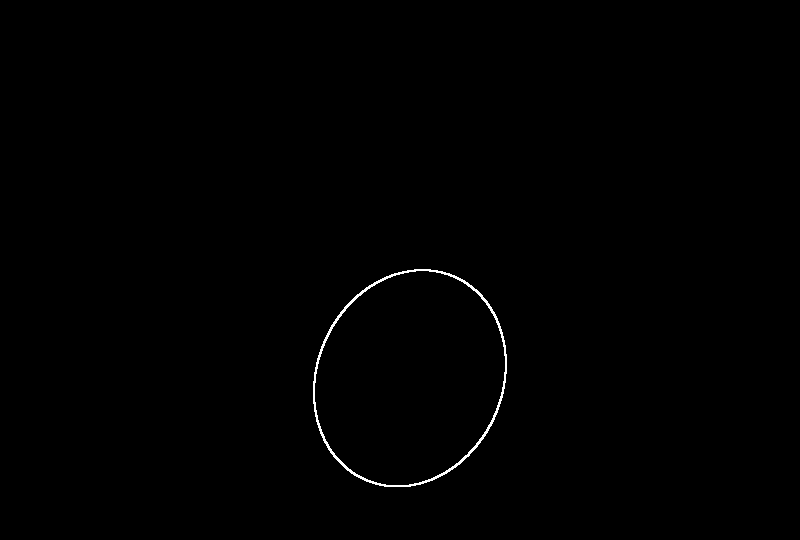

In [5]:
ann_img_path_sample = '/content/drive/MyDrive/Aakash_RB_research/task_1_segmentation/Python_Script/Assets/masks/000_HC_Annotation.png'
img = cv2.imread(ann_img_path_sample)

# Check the shape
print(img.shape)

# To store them in variables:
height, width, channels = img.shape
print(f"Height: {height}, Width: {width}, Channels: {channels}")
cv2_imshow(img)

# Data preprocessing and saving them

In [ ]:
# Create the output directory if it doesn't exist
if not os.path.exists(binary_mask_path):
    os.makedirs(binary_mask_path)

# Loop through all files in the input directory
for filename in os.listdir(ann_img_path):
    if filename.endswith((".png", ".jpg", ".jpeg")): # Process only image files

        # 1. Read the image
        img_full_path = os.path.join(ann_img_path, filename)
        img = cv2.imread(img_full_path)

        if img is None:
            print(f"Skipping {filename}: Could not read image.")
            continue

        # 2. Convert to grayscale and threshold
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, binary_mask = cv2.threshold(gray_img, 10, 255, cv2.THRESH_BINARY)

        # 3. Find and fill contours
        contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        filled_binary_mask = np.zeros_like(binary_mask)
        cv2.drawContours(filled_binary_mask, contours, -1, 255, -1)

        # 4. Save the result to the binary_mask_path
        save_path = os.path.join(binary_mask_path, filename)
        cv2.imwrite(save_path, filled_binary_mask)

        print(f"Processed and saved: {filename}")

print("--- All images processed successfully ---")

Processed and saved: 090_HC_Annotation.png
Processed and saved: 088_2HC_Annotation.png
Processed and saved: 074_HC_Annotation.png
Processed and saved: 041_HC_Annotation.png
Processed and saved: 083_HC_Annotation.png
Processed and saved: 068_HC_Annotation.png
Processed and saved: 082_2HC_Annotation.png
Processed and saved: 073_HC_Annotation.png
Processed and saved: 056_HC_Annotation.png
Processed and saved: 079_HC_Annotation.png
Processed and saved: 063_2HC_Annotation.png
Processed and saved: 081_HC_Annotation.png
Processed and saved: 060_HC_Annotation.png
Processed and saved: 077_HC_Annotation.png
Processed and saved: 063_HC_Annotation.png
Processed and saved: 057_HC_Annotation.png
Processed and saved: 064_2HC_Annotation.png
Processed and saved: 069_HC_Annotation.png
Processed and saved: 059_HC_Annotation.png
Processed and saved: 047_HC_Annotation.png
Processed and saved: 054_HC_Annotation.png
Processed and saved: 049_HC_Annotation.png
Processed and saved: 065_HC_Annotation.png
Process